In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd "/content/drive/MyDrive/Courses/AI/masked_attention/llama_like"

/content/drive/MyDrive/Courses/AI/masked_attention/llama_like


In [3]:
import sys
sys.path.append("/content/drive/MyDrive/Courses/AI/masked_attention/")

In [5]:
import torch
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from src.model import ModelConfig, GroupedQueryAttention, precompute_rope_freqs, apply_rope

In [6]:
# ---------------------------------------------------------------------------
# Config — small enough to inspect visually
# ---------------------------------------------------------------------------
cfg = ModelConfig(
    vocab_size  = 256,
    d_model     = 32,
    n_heads     = 4,       # Q heads
    n_kv_heads  = 2,       # K/V heads  →  each KV head shared by 2 Q heads
    d_ff        = 64,
    max_seq_len = 16,
)

T      = 10   # sequence length
B      = 1    # batch size
D      = cfg.d_model
Hq     = cfg.n_heads
Hkv    = cfg.n_kv_heads
n_rep  = Hq // Hkv          # = 2: each KV head is repeated for 2 Q heads
head_dim = D // Hq


In [7]:
# ---------------------------------------------------------------------------
# 1. Build a dummy input and project Q, K, V
# ---------------------------------------------------------------------------
torch.manual_seed(42)
x = torch.randn(B, T, D)

attn = GroupedQueryAttention(cfg)
attn.eval()

with torch.no_grad():
    q = attn.Wq(x).reshape(B, T, Hq,  head_dim)   # (1, T, 4, head_dim)
    k = attn.Wk(x).reshape(B, T, Hkv, head_dim)   # (1, T, 2, head_dim)
    v = attn.Wv(x).reshape(B, T, Hkv, head_dim)   # (1, T, 2, head_dim)

    rope_freqs = precompute_rope_freqs(head_dim, cfg.max_seq_len)
    q = apply_rope(q, rope_freqs)
    k = apply_rope(k, rope_freqs)

print("=" * 60)
print("STEP 1 — Shapes after projection")
print("=" * 60)
print(f"  Input x       : {list(x.shape)}         (B, T, D)")
print(f"  Q             : {list(q.shape)}   (B, T, Hq={Hq},  head_dim={head_dim})")
print(f"  K             : {list(k.shape)}   (B, T, Hkv={Hkv}, head_dim={head_dim})")
print(f"  V             : {list(v.shape)}   (B, T, Hkv={Hkv}, head_dim={head_dim})")
print(f"\n  → {Hkv} KV heads must serve {Hq} Q heads  (n_rep={n_rep})")

STEP 1 — Shapes after projection
  Input x       : [1, 10, 32]         (B, T, D)
  Q             : [1, 10, 4, 8]   (B, T, Hq=4,  head_dim=8)
  K             : [1, 10, 2, 8]   (B, T, Hkv=2, head_dim=8)
  V             : [1, 10, 2, 8]   (B, T, Hkv=2, head_dim=8)

  → 2 KV heads must serve 4 Q heads  (n_rep=2)


In [8]:
# ---------------------------------------------------------------------------
# 2. KV expansion — show what repeat does
# ---------------------------------------------------------------------------
k_expanded = k.unsqueeze(3).expand(B, T, Hkv, n_rep, head_dim).reshape(B, T, Hq, head_dim)
v_expanded = v.unsqueeze(3).expand(B, T, Hkv, n_rep, head_dim).reshape(B, T, Hq, head_dim)

print("\n" + "=" * 60)
print("STEP 2 — KV expansion (repeat each KV head n_rep times)")
print("=" * 60)
print(f"  K before expand : {list(k.shape)}")
print(f"  K after  expand : {list(k_expanded.shape)}")
print(f"\n  Head assignment (Q head → KV head it uses):")
for qh in range(Hq):
    kvh = qh // n_rep
    print(f"    Q head {qh}  →  KV head {kvh}")

# Verify: heads that share KV must have identical K tensors
print(f"\n  Verifying shared weights are identical:")
for kvh in range(Hkv):
    q_heads = [qh for qh in range(Hq) if qh // n_rep == kvh]
    match = torch.allclose(
        k_expanded[0, :, q_heads[0], :],
        k_expanded[0, :, q_heads[1], :]
    )
    print(f"    KV head {kvh} → Q heads {q_heads}  |  K tensors identical: {match}")


STEP 2 — KV expansion (repeat each KV head n_rep times)
  K before expand : [1, 10, 2, 8]
  K after  expand : [1, 10, 4, 8]

  Head assignment (Q head → KV head it uses):
    Q head 0  →  KV head 0
    Q head 1  →  KV head 0
    Q head 2  →  KV head 1
    Q head 3  →  KV head 1

  Verifying shared weights are identical:
    KV head 0 → Q heads [0, 1]  |  K tensors identical: True
    KV head 1 → Q heads [2, 3]  |  K tensors identical: True


In [9]:
# ---------------------------------------------------------------------------
# 3. Attention scores per Q head
# ---------------------------------------------------------------------------
# Transpose: (B, H, T, head_dim)
q_t = q.transpose(1, 2)
k_t = k_expanded.transpose(1, 2)
v_t = v_expanded.transpose(1, 2)

scale  = math.sqrt(head_dim)
scores = torch.matmul(q_t, k_t.transpose(-2, -1)) / scale   # (B, Hq, T, T)

# Causal mask
mask = torch.tril(torch.ones(T, T))
scores_masked = scores.masked_fill(mask.unsqueeze(0).unsqueeze(0) == 0, float("-inf"))
attn_weights  = F.softmax(scores_masked, dim=-1)             # (B, Hq, T, T)

print("\n" + "=" * 60)
print("STEP 3 — Attention weight statistics per Q head")
print("=" * 60)
print(f"  {'Q head':<10} {'KV head':<10} {'mean attn':<14} {'max attn':<14} {'entropy'}")
print(f"  {'-'*6:<10} {'-'*7:<10} {'-'*9:<14} {'-'*8:<14} {'-'*7}")
for qh in range(Hq):
    kvh      = qh // n_rep
    w        = attn_weights[0, qh]                    # (T, T)
    valid    = w[~w.isnan()]
    mean_w   = valid.mean().item()
    max_w    = valid.max().item()
    # entropy over last non-masked position
    last_row = w[-1]
    ent      = -(last_row * last_row.clamp(min=1e-9).log()).sum().item()
    print(f"  {qh:<10} {kvh:<10} {mean_w:<14.4f} {max_w:<14.4f} {ent:.4f}")

print(f"\n  → Q heads sharing the same KV head produce DIFFERENT attention")
print(f"    patterns because their Q projections differ.")


STEP 3 — Attention weight statistics per Q head
  Q head     KV head    mean attn      max attn       entropy
  ------     -------    ---------      --------       -------
  0          0          0.1000         1.0000         2.2644
  1          0          0.1000         1.0000         2.2871
  2          1          0.1000         1.0000         2.2955
  3          1          0.1000         1.0000         2.2107

  → Q heads sharing the same KV head produce DIFFERENT attention
    patterns because their Q projections differ.



✓ Plot saved to gqa_inspection.png


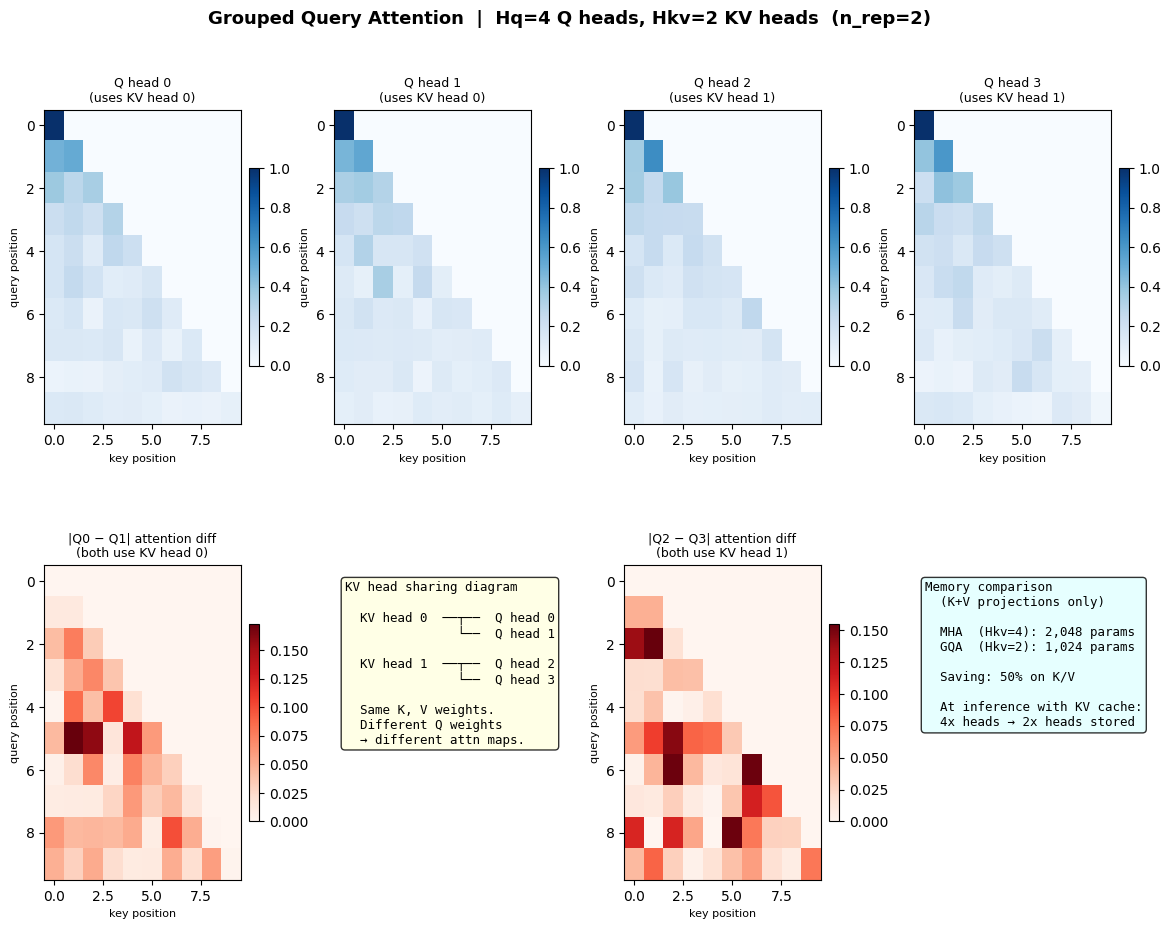

In [10]:
# ---------------------------------------------------------------------------
# 4. Visualization
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(14, 10))
fig.suptitle(
    f"Grouped Query Attention  |  Hq={Hq} Q heads, Hkv={Hkv} KV heads  (n_rep={n_rep})",
    fontsize=13, fontweight="bold"
)

gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

# ── Row 0: attention weight heatmaps per Q head ───────────────────────────
for qh in range(Hq):
    ax  = fig.add_subplot(gs[0, qh])
    kvh = qh // n_rep
    w   = attn_weights[0, qh].detach().numpy()
    im  = ax.imshow(w, vmin=0, vmax=1, cmap="Blues", aspect="auto")
    ax.set_title(f"Q head {qh}\n(uses KV head {kvh})", fontsize=9)
    ax.set_xlabel("key position", fontsize=8)
    ax.set_ylabel("query position", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ── Row 1: difference maps between Q heads sharing the same KV ────────────
pair_axes = [fig.add_subplot(gs[1, i]) for i in range(4)]

for idx, (kvh, (qa, qb)) in enumerate(
        [(0, (0, 1)), (1, (2, 3))]):
    ax   = pair_axes[idx * 2]
    diff = (attn_weights[0, qa] - attn_weights[0, qb]).detach().abs().numpy()
    im   = ax.imshow(diff, cmap="Reds", aspect="auto")
    ax.set_title(
        f"|Q{qa} − Q{qb}| attention diff\n(both use KV head {kvh})", fontsize=9
    )
    ax.set_xlabel("key position", fontsize=8)
    ax.set_ylabel("query position", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ── KV sharing diagram (text panel) ───────────────────────────────────────
ax_diag = pair_axes[1]
ax_diag.axis("off")
lines = [
    "KV head sharing diagram",
    "",
    f"  KV head 0  ──┬──  Q head 0",
    f"               └──  Q head 1",
    "",
    f"  KV head 1  ──┬──  Q head 2",
    f"               └──  Q head 3",
    "",
    f"  Same K, V weights.",
    f"  Different Q weights",
    f"  → different attn maps.",
]
ax_diag.text(0.05, 0.95, "\n".join(lines), transform=ax_diag.transAxes,
             fontsize=9, verticalalignment="top", fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

ax_mem = pair_axes[3]
ax_mem.axis("off")
mha_params = Hq  * head_dim * D * 2   # K + V for full MHA
gqa_params = Hkv * head_dim * D * 2   # K + V for GQA
saving     = (1 - gqa_params / mha_params) * 100
lines2 = [
    "Memory comparison",
    f"  (K+V projections only)",
    "",
    f"  MHA  (Hkv={Hq}): {mha_params:,} params",
    f"  GQA  (Hkv={Hkv}): {gqa_params:,} params",
    "",
    f"  Saving: {saving:.0f}% on K/V",
    "",
    f"  At inference with KV cache:",
    f"  {Hq}x heads → {Hkv}x heads stored",
]
ax_mem.text(0.05, 0.95, "\n".join(lines2), transform=ax_mem.transAxes,
            fontsize=9, verticalalignment="top", fontfamily="monospace",
            bbox=dict(boxstyle="round", facecolor="lightcyan", alpha=0.8))

plt.savefig("gqa_inspection.png", dpi=150, bbox_inches="tight")
print("\n✓ Plot saved to gqa_inspection.png")
plt.show()
